# \(B^\pm\to K^\pm K^\pm K^\mp\) — simultaneous direct-CP amplitude fit

This notebook targets the current **`main`** public API of `DalitzPlotFitter`.

Final convention:

- fit variables are fully **unfolded**; the two identical \(K^+\) are
  particles \((0,1)\) in `('K+', 'K+', 'K-')`, so `Resonance` amplitudes are
  automatically symmetrized and the unbinned fit is already correct without
  any folding of the fit sample itself;
- ROOT `s31` is mapped to internal `s13`;
- invariants are in GeV²;
- all resonances use pair `(0,2)`;
- `normalize_components=True`;
- normalization uses `toy-mc`: one flat 1,000,000-event `PhaseSpaceMC`
  sample, generated once and shared unchanged between the B+ and B- models
  (`normalization_sample=`), so integration noise does not differ between
  charges;
- the Laura++ `LauRescattering2Res` port (`Rescattering2`) is included as a coherent spin-0 K+K- amplitude;
- a D0 -> K+K- veto removes +/-60 MeV around the D0 mass, and a J/psi ->
  K+K- veto removes +/-30 MeV around the J/psi mass, both in each opposite-sign
  K+K- pairing (`s13` and `s23`) and both charges; both half-widths are
  configurable (`D0_VETO_HALF_WIDTH_GEV`, `JPSI_VETO_HALF_WIDTH_GEV`). The
  model does not fit an explicit `Jpsi_1S` component — that region is
  excised by the veto instead;
- only the BaBar Table-I baseline amplitudes are fit, with the ad hoc
  `X0(1550)` pole replaced by the established `f0(1500)` and `f2'(1525)`
  resonances: `phi1020`, `f0_980`, `rescattering2`, `f0_1500`, `f2p_1525`,
  `f0_1710`, `phi1680`, `chic0`, `NR` — the previous additional test
  amplitudes (`f2_1270`, `chic2`) have been removed;
- background and efficiency are built directly from the ROOT files' own
  `mPrime`/`thPrime` branches, which are already folded onto
  \(\theta'\in[0,0.5]\) for the identical-\(K^+\) pair `SQDP_PAIR=(0,1)`
  (verified numerically against the reconstructed candidate mass) —
  `SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` are
  built directly on that half-domain with `folded=True`, no manual
  mirroring needed. The same pair is used for postfit Square-Dalitz
  visualization, and postfit data panels plot the real `mPrime`/`thPrime`
  branches directly (masked by the same D0/J-psi veto as the fit data)
  rather than recomputing them;
- postfit plots include `s13`, `s23`, `m13`, `m23`,
  1D SqDP projections (`mPrime`, `thetaPrime`), full 2D SqDP, and the
  unfolded Dalitz plane; prefit plots are skipped in this run;
- Minuit defaults: verbosity 3, strategy 1;
- the fit is **extended** (`CPFitSession(extended=True, signal_yield=...)`):
  the total signal yield `N_signal` and the raw signal yield asymmetry
  `A_yield` between B+ and B- are independent fit parameters via
  `YieldAsymmetry`, and the combinatorial background gets its own
  independent yield `N_combinatorial` (`with_background(..., yield_=...)`)
  instead of a shared `signal_fraction`. `A_yield` is a raw counting CP
  asymmetry, distinct from `CPRealImag`'s coefficient-level `A_CP` reported
  below (see `docs/cp_coefficients.md`, "Yield-asymmetry parameterization").

Efficiency is built separately for B+ and B- from
`mclarge151617_kkk.root`, after applying the same data mass window, directly
from its `mPrime`/`thPrime` branches, histogrammed with
`weights=Event_PIDCalibEff` (sum of weights per bin) and smoothed.

Events with non-positive `Event_PIDCalibEff` are reported for diagnostics and excluded from the efficiency-map sample. The map itself is still filled with `weights=Event_PIDCalibEff`, i.e. the sum of weights in each bin.

Before filling the efficiency map, MC events with non-finite `mPrime`/`thPrime`, coordinates outside the folded SqDP domain, non-finite `Event_PIDCalibEff`, or `Event_PIDCalibEff <= 0` are reported and removed.

Implementation note: the notebook delegates fitting to `CPFitSession.fit`
(or `fit_multistart`) and delegates folded Square-Dalitz histogram
evaluation to `SquareDalitzHistogramBackground`/
`SquareDalitzHistogramEfficiency`. Custom code is retained only to build the
already-folded `(mPrime, thPrime)` histograms from ROOT, smooth them, and
render the postfit diagnostics not exposed by the public session API.


In [1]:

from dataclasses import dataclass, replace
from pathlib import Path
import inspect

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    BaBarFlatte,
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DalitzAmplitude,
    MassWindowVeto,
    DecayChannel,
    DecayModel,
    Parameter,
    PhaseSpaceMC,
    Resonance,
    Rescattering2,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    YieldAsymmetry,
    enable_x64,
    fold_thetaprime,
    invariants_to_square_dalitz,
    plot_binned_data,
    plot_dalitz,
    plot_square_dalitz,
    read_phase_space_sample,
    read_root_tree,
)

enable_x64()

# Fail early if an older checkout is accidentally used.
_fit_signature = inspect.signature(CPFitSession.fit)
if 'strategy' not in _fit_signature.parameters or 'hesse' not in _fit_signature.parameters:
    raise RuntimeError(
        "This notebook requires the current DalitzPlotFitter main branch: "
        "CPFitSession.fit must expose strategy= and hesse=."
    )


## Configuration

In [2]:
ROOT_FILE = Path('/home/juan-leite/Work/data/B2KKK_data.root')
TREE_NAME = 'DecayTree'

MC_FILE = Path('/home/juan-leite/Work/data/mclarge151617_kkk.root')
MC_TREE_NAME = 'DecayTree'

BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    's12': 's12',
    's13': 's31',
    's23': 's23',
    # Already-folded Square-Dalitz coordinates (thPrime in [0, 0.5]).
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
}

MC_BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
    'pid_eff': 'Event_PIDCalibEff',
}

INVARIANT_UNIT = 'GeV2'

BPLUS_CHARGE_VALUE = +1
BMINUS_CHARGE_VALUE = -1

SIGNAL_MASS_WINDOW = (5230.0, 5330.0)
BKG_MASS_MIN = 5500.0

D0_MASS_GEV = 1.86484
D0_VETO_HALF_WIDTH_GEV = 0.060

# J/psi(1S) -> K+K- veto, same window convention as the D0 veto above
# (configurable half-width, applied to both opposite-sign K+K- pairings and
# both charges); the model itself no longer fits a Jpsi_1S component.
JPSI_MASS_GEV = 3.096900
JPSI_VETO_HALF_WIDTH_GEV = 0.030

M_B_GEV = 5.27934
M_K_GEV = 0.493677
DAUGHTER_MASSES = (M_K_GEV, M_K_GEV, M_K_GEV)

# The two identical K+ are particles (0, 1) in ('K+', 'K+', 'K-'); this is
# the pair that must be used for the Square-Dalitz (m', theta') convention
# for `folded=True` to be valid (exchanging it leaves m' fixed and maps
# theta' -> 1 - theta'), and it matches the pair used to compute the ROOT
# files' own mPrime/thPrime branches (verified numerically against B_m).
# Used both for postfit visualization (plot_square_dalitz/square_coordinates)
# and for the folded background/efficiency Square-Dalitz histograms below.
SQDP_PAIR = (0, 1)

# toy-mc normalization: one shared flat phase-space sample (same masses for
# both charges) reused for both plus_model and minus_model, so integration
# noise does not differ between B+ and B- and bias the charge asymmetry.
NORMALIZATION_MC_SIZE = 1_000_000
NORMALIZATION_MC_SEED = 20260910

# (mPrime bins, thetaPrime-half bins): mPrime spans [0, 1], thetaPrime spans
# [0, 0.5] since the histograms are built directly from the already-folded
# ROOT mPrime/thPrime branches and evaluated with folded=True.
SEPARATE_BKG_BY_CHARGE = False
BACKGROUND_BINS = (45, 45)
BACKGROUND_SMOOTH_SIGMA = 1.0

USE_EFFICIENCY = True
EFFICIENCY_BINS = (45, 45)
EFFICIENCY_SMOOTH_SIGMA = 1.0

# Extended fit: N_signal, A_yield and N_combinatorial are known from an
# external measurement (e.g. an extended ML fit to the B mass spectrum) and
# are fixed (not floated) in this Dalitz fit -- only the amplitude
# parameters are free. YieldAsymmetry's raw counting asymmetry
# A_yield = (N_minus - N_plus) / N_s is independent of CPRealImag's
# coefficient-level A_CP (see docs/cp_coefficients.md).
SIGNAL_YIELD = 323_514  # TODO: set to the known N_signal
YIELD_ASYMMETRY = -0.037  # TODO: set to the known A_yield
BACKGROUND_YIELD =  11_826 + 30 # TODO: set to the known N_combinatorial

FIT_NSTARTS = 1
FIT_SEED = 20260903
FIT_TOLERANCE = 1e-4
FIT_VERBOSE = 3
FIT_STRATEGY = 1

PROJECTION_SIZE = 1_000_000
PROJECTION_BINS = 100

## Load unfolded signal data and folded sideband SqDP

In [3]:
def signal_cut(charge=None):
    lo, hi = SIGNAL_MASS_WINDOW
    cut = f"({BRANCH['mass']} >= {lo}) & ({BRANCH['mass']} <= {hi})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def sideband_cut(charge=None):
    cut = f"({BRANCH['mass']} > {BKG_MASS_MIN})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def convert_to_gev2(sample):
    if INVARIANT_UNIT == 'GeV2':
        return sample
    if INVARIANT_UNIT != 'MeV2':
        raise ValueError("INVARIANT_UNIT must be 'GeV2' or 'MeV2'")

    scale = 1e-6
    return PhaseSpaceSample(
        s12=jnp.asarray(sample.s12) * scale,
        s13=jnp.asarray(sample.s13) * scale,
        s23=jnp.asarray(sample.s23) * scale,
        weights=jnp.asarray(sample.weights),
        p1=sample.p1,
        p2=sample.p2,
        p3=sample.p3,
    )


def load_signal_sample(charge):
    sample = read_phase_space_sample(
        ROOT_FILE,
        TREE_NAME,
        s12=BRANCH['s12'],
        s13=BRANCH['s13'],
        s23=BRANCH['s23'],
        cut=signal_cut(charge),
    )
    return convert_to_gev2(sample)


def load_sideband_sqdp(charge):
    """Sideband events' already-folded (mPrime, thPrime), read directly."""
    return read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=sideband_cut(charge),
    )


def _mass_veto(mass_gev, half_width_gev):
    """CompositeVeto removing |m(KK) - mass_gev| <= half_width_gev in both
    opposite-sign K+K- pairings ((0,2) and (1,2))."""
    return CompositeVeto(
        MassWindowVeto((0, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
        MassWindowVeto((1, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
    )


D0_VETO = _mass_veto(D0_MASS_GEV, D0_VETO_HALF_WIDTH_GEV)
JPSI_VETO = _mass_veto(JPSI_MASS_GEV, JPSI_VETO_HALF_WIDTH_GEV)
CHARM_VETO = CompositeVeto(D0_VETO, JPSI_VETO)

_samples_before_veto = {
    'plus': load_signal_sample(BPLUS_CHARGE_VALUE),
    'minus': load_signal_sample(BMINUS_CHARGE_VALUE),
}
_samples_after_d0 = {
    charge: D0_VETO.apply(sample)
    for charge, sample in _samples_before_veto.items()
}
samples = {
    charge: JPSI_VETO.apply(sample)
    for charge, sample in _samples_after_d0.items()
}

for charge in ('plus', 'minus'):
    before = _samples_before_veto[charge].size
    after_d0 = _samples_after_d0[charge].size
    after_jpsi = samples[charge].size
    print(
        f"D0->KK veto   {charge:5s}: removed {before-after_d0:,} / {before:,} "
        f"events in |m(KK)-m(D0)| <= {1000.0*D0_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )
    print(
        f"J/psi->KK veto {charge:5s}: removed {after_d0-after_jpsi:,} / {after_d0:,} "
        f"events in |m(KK)-m(J/psi)| <= {1000.0*JPSI_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )


def load_signal_sqdp(charge_value, charge_key):
    """Signal-window (mPrime, thPrime), masked to match samples[charge_key]
    exactly: same signal_cut, then the same CHARM_VETO acceptance computed
    from the s13/s23 branches read alongside."""
    raw = read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            's13': BRANCH['s13'],
            's23': BRANCH['s23'],
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=signal_cut(charge_value),
    )
    mask = np.asarray(
        CHARM_VETO.accept({'s13': jnp.asarray(raw['s13']), 's23': jnp.asarray(raw['s23'])})
    )
    coords = {
        'mprime': np.asarray(raw['mprime'])[mask],
        'thetaprime': np.asarray(raw['thetaprime'])[mask],
    }
    if coords['mprime'].size != samples[charge_key].size:
        raise RuntimeError(
            f"{charge_key}: signal_sqdp size {coords['mprime'].size} != "
            f"samples size {samples[charge_key].size}"
        )
    return coords


signal_sqdp = {
    'plus': load_signal_sqdp(BPLUS_CHARGE_VALUE, 'plus'),
    'minus': load_signal_sqdp(BMINUS_CHARGE_VALUE, 'minus'),
}

bkg_sqdp = {
    'plus': load_sideband_sqdp(BPLUS_CHARGE_VALUE),
    'minus': load_sideband_sqdp(BMINUS_CHARGE_VALUE),
    'all': load_sideband_sqdp(None),
}

raw_control = read_root_tree(
    ROOT_FILE,
    TREE_NAME,
    {'mass': BRANCH['mass'], 'charge': BRANCH['charge']},
)
raw_control = {name: np.asarray(values) for name, values in raw_control.items()}

print(f"B+ signal events: {samples['plus'].size:,}")
print(f"B- signal events: {samples['minus'].size:,}")
print(f"ROOT candidates:  {len(raw_control['mass']):,}")
def mc_signal_cut(charge):
    """Use exactly the data signal-mass window and one B charge."""
    lo, hi = SIGNAL_MASS_WINDOW
    return (
        f"({MC_BRANCH['mass']} >= {lo}) & "
        f"({MC_BRANCH['mass']} <= {hi}) & "
        f"({MC_BRANCH['charge']} == {charge})"
    )


def load_efficiency_mc(charge):
    """Load the already-folded (mPrime, thPrime) and PID weight from MC."""
    return read_root_tree(
        MC_FILE,
        MC_TREE_NAME,
        {
            'mprime': MC_BRANCH['mprime'],
            'thetaprime': MC_BRANCH['thetaprime'],
            'pid_eff': MC_BRANCH['pid_eff'],
        },
        cut=mc_signal_cut(charge),
    )


def sanitize_efficiency_mc(coords, charge_label):
    """Remove entries that cannot contribute to a physical efficiency map."""
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)

    finite_mp = np.isfinite(mp)
    finite_tp = np.isfinite(tp)
    finite_pid = np.isfinite(pid_eff)

    valid = (
        finite_mp
        & finite_tp
        & finite_pid
        & (mp >= 0.0)
        & (mp <= 1.0)
        & (tp >= 0.0)
        & (tp <= 0.5)
        & (pid_eff > 0.0)
    )

    n_total = int(mp.size)
    n_valid = int(np.count_nonzero(valid))
    n_removed = n_total - n_valid

    print(f"\nEfficiency MC sanitation: {charge_label}")
    print(f"  total in mass/charge selection : {n_total:,}")
    print(f"  valid for efficiency map       : {n_valid:,}")
    print(
        f"  removed                        : {n_removed:,} "
        f"({100.0*n_removed/max(n_total,1):.5f}%)"
    )
    print(f"    non-finite mPrime             : {np.count_nonzero(~finite_mp):,}")
    print(f"    non-finite thPrime            : {np.count_nonzero(~finite_tp):,}")
    print(f"    non-finite Event_PIDCalibEff  : {np.count_nonzero(~finite_pid):,}")
    print(
        "    finite PID efficiency <= 0    : "
        f"{np.count_nonzero(finite_pid & (pid_eff <= 0.0)):,}"
    )

    if n_valid == 0:
        raise RuntimeError(f"{charge_label}: no valid efficiency-MC events")

    return {
        'mprime': jnp.asarray(mp[valid]),
        'thetaprime': jnp.asarray(tp[valid]),
        'pid_eff': jnp.asarray(pid_eff[valid]),
    }


efficiency_mc_raw = {
    'plus': load_efficiency_mc(BPLUS_CHARGE_VALUE),
    'minus': load_efficiency_mc(BMINUS_CHARGE_VALUE),
}

efficiency_mc = {
    'plus': sanitize_efficiency_mc(efficiency_mc_raw['plus'], 'B+'),
    'minus': sanitize_efficiency_mc(efficiency_mc_raw['minus'], 'B-'),
}

print(f"\nEfficiency MC retained B+: {len(efficiency_mc['plus']['mprime']):,}")
print(f"Efficiency MC retained B-: {len(efficiency_mc['minus']['mprime']):,}")

D0->KK veto   plus : removed 3,894 / 190,341 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto plus : removed 7,259 / 186,447 events in |m(KK)-m(J/psi)| <= 30 MeV
D0->KK veto   minus: removed 3,763 / 172,511 events in |m(KK)-m(D0)| <= 60 MeV
J/psi->KK veto minus: removed 6,150 / 168,748 events in |m(KK)-m(J/psi)| <= 30 MeV
B+ signal events: 179,188
B- signal events: 162,598
ROOT candidates:  529,235

Efficiency MC sanitation: B+
  total in mass/charge selection : 1,287,105
  valid for efficiency map       : 1,286,803
  removed                        : 302 (0.02346%)
    non-finite mPrime             : 0
    non-finite thPrime            : 0
    non-finite Event_PIDCalibEff  : 0
    finite PID efficiency <= 0    : 302

Efficiency MC sanitation: B-
  total in mass/charge selection : 1,275,743
  valid for efficiency map       : 1,275,433
  removed                        : 310 (0.02430%)
    non-finite mPrime             : 0
    non-finite thPrime            : 1
    non-finite Event_PIDCali

In [4]:

def validate_inputs():
    for charge, sample in samples.items():
        for variable in ('s12', 's13', 's23'):
            values = np.asarray(getattr(sample, variable), dtype=float)
            if np.any(~np.isfinite(values)):
                raise RuntimeError(f"{charge}: non-finite {variable}")

        s13 = np.asarray(sample.s13, dtype=float)
        s23 = np.asarray(sample.s23, dtype=float)
        print(
            f"{charge:5s}: "
            f"s13=[{s13.min():.4f},{s13.max():.4f}] GeV^2, "
            f"s23=[{s23.min():.4f},{s23.max():.4f}] GeV^2, "
            f"fraction(s13>s23)={np.mean(s13 > s23):.3f}"
        )

    for charge, coords in signal_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if coords['mprime'].size != samples[charge].size:
            raise RuntimeError(f"{charge}: signal_sqdp size mismatch with samples")
        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"{charge}: non-finite mPrime/thPrime")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"{charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"{charge}: thPrime outside [0,0.5]")

        print(
            f"{charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    for charge, coords in bkg_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"BKG {charge}: non-finite SqDP coordinates")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"BKG {charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"BKG {charge}: thPrime outside [0,0.5]")

        print(
            f"BKG {charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    # Efficiency samples have already been sanitized; these are internal checks.
    for charge, coords in efficiency_mc.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)
        pid_eff = np.asarray(coords['pid_eff'], dtype=float)

        assert np.all(np.isfinite(mp))
        assert np.all(np.isfinite(tp))
        assert np.all(np.isfinite(pid_eff))
        assert np.all((0.0 <= mp) & (mp <= 1.0))
        assert np.all((0.0 <= tp) & (tp <= 0.5))
        assert np.all(pid_eff > 0.0)

        print(
            f"EFF {charge:5s}: N={len(mp):,}, "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}], "
            f"Event_PIDCalibEff=[{pid_eff.min():.6g},{pid_eff.max():.6g}]"
        )


validate_inputs()


plus : s13=[0.9749,23.3031] GeV^2, s23=[0.9749,23.3414] GeV^2, fraction(s13>s23)=0.500
minus: s13=[0.9750,23.3030] GeV^2, s23=[0.9750,23.2199] GeV^2, fraction(s13>s23)=0.499
plus : mPrime=[0.0092,1.0000], thPrime=[0.0001,0.5000]
minus: mPrime=[0.0157,0.9993], thPrime=[0.0001,0.5000]
BKG plus : mPrime=[0.0132,0.9993], thPrime=[0.0001,0.5000]
BKG minus: mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
BKG all  : mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
EFF plus : N=1,286,803, mPrime=[0.0013,0.9999], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0156231,5.66502]
EFF minus: N=1,275,433, mPrime=[0.0010,1.0000], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0159426,47.6501]


## Folded background/efficiency histograms and display-only Square-Dalitz coordinates

In [5]:

def square_coordinates(data):
    """Folded Square-Dalitz coordinates (pair=SQDP_PAIR), for samples that
    only carry (s12, s13, s23) — i.e. generated toy/component samples. theta'
    is folded onto [0, 0.5] to match signal_sqdp/bkg_sqdp's real mPrime/
    thPrime branches, which are already folded onto that half in the ROOT
    files; without this fold, postfit model curves would spill into
    theta' in [0.5, 1] while the data panel has none there, making the two
    incomparable. Real data uses those ROOT branches directly instead of
    recomputing them here."""
    mp, tp = invariants_to_square_dalitz(
        jnp.asarray(data['s12']),
        jnp.asarray(data['s13']),
        jnp.asarray(data['s23']),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
    )
    return mp, fold_thetaprime(tp)


def smooth_histogram(values, sigma):
    values = np.asarray(values, dtype=float)
    if sigma is None or sigma <= 0:
        return values

    from scipy.ndimage import gaussian_filter
    return gaussian_filter(values, sigma=float(sigma), mode='nearest')


def build_background_map(coords, bins=BACKGROUND_BINS, sigma=BACKGROUND_SMOOTH_SIGMA):
    """Already-folded (mPrime, thPrime) sideband histogram -> smoothing ->
    SquareDalitzHistogramBackground(folded=True).

    thPrime in the ROOT files is already folded onto [0, 0.5] for the
    identical-K+ pair SQDP_PAIR, so the histogram is built directly on that
    half-domain; folded=True folds any query point onto it again at
    evaluation time (evaluated from the fit's own s12/s13/s23 via
    invariants_to_square_dalitz), so no explicit mirroring is needed.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    nx, ny = bins

    hist, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)),
    )

    hist = smooth_histogram(hist, sigma)
    hist = np.maximum(hist, 0.0)

    if not np.any(hist > 0.0):
        raise RuntimeError("Empty sideband histogram")

    model = SquareDalitzHistogramBackground(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(hist),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (hist, mp_edges, tp_edges)


def build_efficiency_map(coords, bins=EFFICIENCY_BINS, sigma=EFFICIENCY_SMOOTH_SIGMA):
    """PID-weighted already-folded (mPrime, thPrime) MC -> smoothing ->
    SquareDalitzHistogramEfficiency(folded=True).

    The histogram is the SUM of Event_PIDCalibEff weights per bin. No
    mean-by-bin and no independent per-charge rescaling are applied.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)
    nx, ny = bins

    weighted, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)), weights=pid_eff,
    )
    weighted = np.maximum(weighted, 0.0)

    if not np.any(weighted > 0.0):
        raise RuntimeError("Empty PID-weighted efficiency histogram")

    smoothed = smooth_histogram(weighted, sigma)
    smoothed = np.maximum(smoothed, 0.0)

    model = SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(smoothed),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (smoothed, mp_edges, tp_edges)


## BABAR Table-I model

In [6]:
COEFFICIENT_STARTS = {
    # BaBar baseline starting values
    'phi1020': dict(rho=1.66, phase=2.99),
    'f0_980': dict(rho=5.20, phase=0.48),
    'rescattering2': dict(rho=0.10, phase=0.00),
    'f0_1500': dict(rho=8.20, phase=1.29),
    'f2p_1525': dict(rho=0.10, phase=0.00),
    'f0_1710': dict(rho=1.22, phase=-0.59),
    'phi1680': dict(rho=0.10, phase=0.00),
    'chic0': dict(rho=0.437, phase=-1.02),
    'NR': dict(rho=13.2, phase=0.00),
}


def polar_to_xy(rho, phase):
    return float(rho * np.cos(phase)), float(rho * np.sin(phase))


def make_cp_coefficients():
    result = {}
    charmonium = {'chic0'}

    for name, config in COEFFICIENT_STARTS.items():
        x0, y0 = polar_to_xy(config['rho'], config['phase'])
        is_reference = name == 'NR'
        is_charmonium = name in charmonium

        # Keep the existing NR global-reference convention.
        x = Parameter.coefficient(
            f'{name}.x',
            x0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )
        y = Parameter.coefficient(
            f'{name}.y',
            y0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )

        # Charmonium nominal convention: no intrinsic direct CPV.
        # NR keeps its existing convention: dx free, dy fixed.
        dx = Parameter.coefficient(
            f'{name}.dx',
            0.0,
            owner=name,
            fixed=is_charmonium,
            step=0.005,
        )
        dy = Parameter.coefficient(
            f'{name}.dy',
            0.0,
            owner=name,
            fixed=(is_reference or is_charmonium),
            step=0.005,
        )

        result[name] = CPRealImag(x, y, dx, dy)

    return result


@dataclass(frozen=True)
class BaBarExponentialNR:
    alpha: object

    def __call__(self, data):
        alpha = jnp.asarray(self.alpha)
        return (
            jnp.exp(-alpha * jnp.asarray(data['s13']))
            + jnp.exp(-alpha * jnp.asarray(data['s23']))
        ) / jnp.sqrt(2.0)


def build_models():
    shared = make_cp_coefficients()

    nr_alpha = Parameter.dynamics(
        'NR.alpha',
        0.152,
        owner='NR',
        bounds=(0.0, 1.0),
        step=0.002,
    )

    def components(charge):
        coefficient = {
            name: cp_coefficient.for_charge(charge)
            for name, cp_coefficient in shared.items()
        }

        return [
            Resonance(
                'phi1020',
                (0, 2),
                coefficient['phi1020'],
                mass=1.019461,
                width=0.004249,
                spin=1,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_980',
                (0, 2),
                coefficient['f0_980'],
                lineshape=BaBarFlatte(),
                mass=0.965,
                width=0.0,
                spin=0,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'rescattering2',
                (0, 2),
                coefficient['rescattering2'],
                lineshape=Rescattering2(),
                # Context pole values are unused by Rescattering2 for L=0;
                # keep a physical KK value so the generic resonance wrapper
                # can build its spin-0 kinematics/barrier context.
                mass=1.47,
                width=0.0,
                spin=0,
                resonance_radius=0.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_1500',
                (0, 2),
                coefficient['f0_1500'],
                mass=1.522,
                width=0.108,
                spin=0,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f2p_1525',
                (0, 2),
                coefficient['f2p_1525'],
                mass=1.5173,
                width=0.0720,
                spin=2,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_1710',
                (0, 2),
                coefficient['f0_1710'],
                mass=1.715,
                width=0.125,
                spin=0,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'phi1680',
                (0, 2),
                coefficient['phi1680'],
                mass=1.680,
                width=0.150,
                spin=1,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            Resonance(
                'chic0',
                (0, 2),
                coefficient['chic0'],
                mass=3.41475,
                width=0.0104,
                spin=0,
                resonance_radius=4.0,
                parent_radius=0.0,
            ),
            DalitzAmplitude(
                'NR',
                dynamics=BaBarExponentialNR(nr_alpha),
                coefficient=coefficient['NR'],
            ),
        ]

    # toy-mc normalization: one flat 1M-event PhaseSpaceMC sample, generated
    # once and reused unchanged for both plus/minus DecayModel instances
    # (same mother/daughter masses for B+ and B-), auto-selecting
    # normalization_method='toy-mc'. No new integration points are drawn
    # during minimization (docs/mc_integration.md).
    #
    # PhaseSpaceMC.generate() weights carry its own proposal measure
    # (ds12 ds13 / (128*pi**3*M**2)); the deterministic grid this replaces
    # integrates in plain ds12 ds13. Rescaling by 128*pi**3*M**2 keeps the
    # same measure so the fitted density and NLL stay on the same absolute
    # scale as the previous gauss-legendre normalization (verified
    # numerically: without this factor the NLL at the BaBar starting values
    # differs by the corresponding huge constant, ~exp(11.6) per event).
    raw_normalization_mc = PhaseSpaceMC(M_B_GEV, DAUGHTER_MASSES).generate(
        NORMALIZATION_MC_SIZE,
        seed=NORMALIZATION_MC_SEED,
        include_momenta=False,
    )
    measure_factor = 128.0 * np.pi**3 * M_B_GEV**2
    normalization_mc = replace(
        raw_normalization_mc,
        weights=raw_normalization_mc.weights * measure_factor,
    )

    plus = DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        components(+1),
        normalize_components=True,
        normalization_sample=normalization_mc,
    )

    minus = DecayModel(
        DecayChannel('B-', ('K-', 'K-', 'K+')),
        components(-1),
        normalize_components=True,
        normalization_sample=normalization_mc,
    )

    return plus, minus, shared


plus_model, minus_model, shared_coefficients = build_models()

print("normalization_method =", plus_model.normalization_method)
print("B+ normalization points =", plus_model.normalization_sample.size)
print("B- normalization points =", minus_model.normalization_sample.size)

normalization_method = toy-mc
B+ normalization points = 1000000
B- normalization points = 1000000


### \(\phi(1680)\)

The model keeps the existing \(f_0(1710)\) amplitude and now also includes
\(\phi(1680)\to K^+K^-\) as a spin-1 Breit-Wigner in `pair=(0,2)`, with fixed
nominal mass and width

\[
m_{\phi(1680)}=1.680~\mathrm{GeV},\qquad
\Gamma_{\phi(1680)}=0.150~\mathrm{GeV}.
\]

Its CP-even and CP-odd coefficient parameters are free, like the other
charmless amplitudes. The initial coefficient magnitude is 0.10 with phase 0.

### CP convention for charmonium

For the nominal model, \(\chi_{c0}\) has

\[
dx=dy=0
\]

fixed. Its CP-even \(x,y\) coefficients remain free. Local CP asymmetry in
that mass region can still arise through interference with the charmless
amplitudes.

The existing NR reference convention is unchanged.

### Rescattering and charm veto

The coherent charmless model also contains the Laura++ two-region rescattering
S-wave through `Rescattering2()`. Its complex CP coefficient is free for the
B+ and B- simultaneous fit using the same `CPRealImag` convention as the other
charmless amplitudes.

A `CompositeVeto` made from two `MassWindowVeto` objects removes

\[
|m(K^+K^-)-m_{D^0}| \le 60\,\mathrm{MeV}
\]

for both opposite-sign pairings, and a second `CompositeVeto` removes

\[
|m(K^+K^-)-m_{J/\psi}| \le 30\,\mathrm{MeV}
\]

(both half-widths configurable via `D0_VETO_HALF_WIDTH_GEV` /
`JPSI_VETO_HALF_WIDTH_GEV`). The two are combined into one `CHARM_VETO`. The
model no longer fits an explicit `Jpsi_1S` component — that mass region is
excised by the veto instead. The same combined veto is applied to the
selected data and to the fit session, so signal normalization, combinatorial
background and fit projections all use the same accepted Dalitz region.


## Simultaneous fit session

In [7]:

def build_session():
    if SEPARATE_BKG_BY_CHARGE:
        plus_background, _ = build_background_map(bkg_sqdp['plus'])
        minus_background, _ = build_background_map(bkg_sqdp['minus'])
    else:
        common_background, _ = build_background_map(bkg_sqdp['all'])
        plus_background = common_background
        minus_background = common_background

    # N_signal, A_yield and N_combinatorial are known (fixed) rather than
    # fit here -- only the amplitude parameters float.
    signal_yield = YieldAsymmetry(
        Parameter(
            'n_signal',
            SIGNAL_YIELD,
            fixed=True,
        ),
        Parameter(
            'a_cp_yield',
            YIELD_ASYMMETRY,
            fixed=True,
        ),
    )

    fit_session = CPFitSession(
        plus_model,
        minus_model,
        samples['plus'],
        samples['minus'],
        extended=True,
        signal_yield=signal_yield,
    )

    if USE_EFFICIENCY:
        plus_efficiency, _ = build_efficiency_map(efficiency_mc['plus'])
        minus_efficiency, _ = build_efficiency_map(efficiency_mc['minus'])
        fit_session = fit_session.with_efficiency(
            plus_efficiency,
            minus_efficiency,
        )

    fit_session = fit_session.with_veto(CHARM_VETO)

    fit_session = fit_session.with_background(
        'combinatorial',
        plus_background,
        minus_shape=minus_background,
        yield_=Parameter(
            'n_combinatorial',
            BACKGROUND_YIELD,
            fixed=True,
        ),
    )

    return fit_session


session = build_session()

for parameter in session.parameters:
    print(
        f"{parameter.name:24s} "
        f"value={parameter.value: .6g} fixed={parameter.fixed}"
    )


phi1020.x                value=-1.64096 fixed=False
phi1020.y                value= 0.250681 fixed=False
phi1020.dx               value= 0 fixed=False
phi1020.dy               value= 0 fixed=False
f0_980.x                 value= 4.61237 fixed=False
f0_980.y                 value= 2.40125 fixed=False
f0_980.dx                value= 0 fixed=False
f0_980.dy                value= 0 fixed=False
rescattering2.x          value= 0.1 fixed=False
rescattering2.y          value= 0 fixed=False
rescattering2.dx         value= 0 fixed=False
rescattering2.dy         value= 0 fixed=False
f0_1500.x                value= 2.27239 fixed=False
f0_1500.y                value= 7.87885 fixed=False
f0_1500.dx               value= 0 fixed=False
f0_1500.dy               value= 0 fixed=False
f2p_1525.x               value= 0.1 fixed=False
f2p_1525.y               value= 0 fixed=False
f2p_1525.dx              value= 0 fixed=False
f2p_1525.dy              value= 0 fixed=False
f0_1710.x                value= 1.01375

## Prefit and postfit helpers

In [8]:
def default_values():
    return {
        parameter.name: float(parameter.value)
        for parameter in session.parameters
    }


def projection_components(values, size=PROJECTION_SIZE, seed=FIT_SEED):
    plus_mc = plus_model.generate_phase_space(size, seed=seed)
    minus_mc = minus_model.generate_phase_space(size, seed=seed + 1)

    plus_components, minus_components = session._projection_components_pair(
        values,
        plus_mc,
        minus_mc,
    )

    return plus_mc, minus_mc, plus_components, minus_components


def plot_one_dimensional(
    values,
    squared,
    title_prefix,
    bins=PROJECTION_BINS,
    size=PROJECTION_SIZE,
    seed=FIT_SEED,
):
    """Folded 1D projections: s_low = min(s13, s23), s_high = max(s13, s23)
    (same event-by-event fold as the background/efficiency maps and the
    SqDP plots above), plotted as two separate spectra -- s_low and s_high
    are genuinely different distributions, not two views of the same one."""
    plus_mc, minus_mc, plus_components, minus_components = projection_components(
        values,
        size=size,
        seed=seed,
    )

    for fold_side in ('low', 'high'):
        fold_fn = np.minimum if fold_side == 'low' else np.maximum
        if squared:
            xlabel = rf"$s_{{\mathrm{{{fold_side}}}}}$ [GeV$^2$]"
        else:
            xlabel = rf"$m_{{\mathrm{{{fold_side}}}}}$ [GeV]"

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

        for ax, charge, data, components in (
            (axes[0], 'B+', samples['plus'], plus_components),
            (axes[1], 'B-', samples['minus'], minus_components),
        ):
            data_values = fold_fn(
                np.asarray(data.s13, dtype=float),
                np.asarray(data.s23, dtype=float),
            )
            if not squared:
                data_values = np.sqrt(np.clip(data_values, 0.0, None))

            edges = np.linspace(data_values.min(), data_values.max(), bins + 1)
            _, counts, _, _ = plot_binned_data(
                data_values,
                bins=edges,
                ax=ax,
                label='data',
            )

            total = np.zeros(bins, dtype=float)

            for name, component_sample, weights in components:
                component_values = fold_fn(
                    np.asarray(component_sample.s13, dtype=float),
                    np.asarray(component_sample.s23, dtype=float),
                )
                if not squared:
                    component_values = np.sqrt(
                        np.clip(component_values, 0.0, None)
                    )

                hist, _ = np.histogram(
                    component_values,
                    bins=edges,
                    weights=np.asarray(weights, dtype=float),
                )
                total += hist
                ax.stairs(hist, edges, label=name)

            ax.stairs(total, edges, linewidth=2.0, label='total model')
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Candidates / bin')
            ax.set_title(f'{title_prefix}: {charge}')
            ax.legend(fontsize=8)

        plt.show()



def plot_sqdp_projections(
    values,
    title_prefix,
    bins=PROJECTION_BINS,
    size=PROJECTION_SIZE,
    seed=FIT_SEED + 50,
):
    """Plot 1D mPrime and thetaPrime projections for B+ and B-.

    Data uses the ROOT mPrime/thPrime branches directly (signal_sqdp);
    generated components use square_coordinates, which folds theta' onto
    [0, 0.5] to match, since they only carry (s12, s13, s23).
    """
    plus_mc, minus_mc, plus_components, minus_components = projection_components(
        values,
        size=size,
        seed=seed,
    )

    for variable, xlabel in (
        ('mprime', r"$m'$"),
        ('thetaprime', r"$\theta'$"),
    ):
        # theta' is folded onto [0, 0.5]; m' spans the full [0, 1].
        variable_max = 1.0 if variable == 'mprime' else 0.5

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(13, 4.8),
            constrained_layout=True,
        )

        for ax, charge, charge_key, mc, components in (
            (axes[0], 'B+', 'plus', plus_mc, plus_components),
            (axes[1], 'B-', 'minus', minus_mc, minus_components),
        ):
            data_values = np.asarray(signal_sqdp[charge_key][variable], dtype=float)

            edges = np.linspace(0.0, variable_max, bins + 1)
            _, counts, _, _ = plot_binned_data(
                data_values,
                bins=edges,
                ax=ax,
                label='data',
            )

            total = np.zeros(bins, dtype=float)

            # Use exactly the same component weights as the fit projections.
            for name, component_sample, weights in components:
                component_mp, component_tp = square_coordinates(
                    component_sample.as_dict()
                )

                if variable == 'mprime':
                    component_values = np.asarray(component_mp, dtype=float)
                else:
                    component_values = np.asarray(component_tp, dtype=float)

                hist, _ = np.histogram(
                    component_values,
                    bins=edges,
                    weights=np.asarray(weights, dtype=float),
                )
                total += hist
                ax.stairs(hist, edges, label=name)

            ax.stairs(
                total,
                edges,
                linewidth=2.0,
                label='total model',
            )

            ax.set_xlim(0.0, variable_max)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Candidates / bin')
            ax.set_title(f'{title_prefix}: {charge} {xlabel}')
            ax.legend(fontsize=8)

        plt.show()


def plot_sqdp_comparison(
    values,
    title_prefix,
    bins=(45, 45),
    size=PROJECTION_SIZE,
    seed=FIT_SEED + 100,
):
    """2D SqDP data/model/pull, folded onto theta' in [0, 0.5]. Data uses the
    ROOT mPrime/thPrime branches directly (signal_sqdp); the model uses
    square_coordinates (also folded) on generated phase space."""
    plus_mc, minus_mc, plus_components, minus_components = projection_components(
        values,
        size=size,
        seed=seed,
    )

    for charge, charge_key, mc, components in (
        ('B+', 'plus', plus_mc, plus_components),
        ('B-', 'minus', minus_mc, minus_components),
    ):
        data_mp = np.asarray(signal_sqdp[charge_key]['mprime'], dtype=float)
        data_tp = np.asarray(signal_sqdp[charge_key]['thetaprime'], dtype=float)
        model_mp, model_tp = square_coordinates(mc.as_dict())

        model_mp = np.asarray(model_mp, dtype=float)
        model_tp = np.asarray(model_tp, dtype=float)

        model_weights = np.zeros(mc.size, dtype=float)
        for _, _, weights in components:
            model_weights += np.asarray(weights, dtype=float)

        data_hist, x_edges, y_edges = np.histogram2d(
            data_mp,
            data_tp,
            bins=bins,
            range=((0.0, 1.0), (0.0, 0.5)),
        )

        model_hist, _, _ = np.histogram2d(
            model_mp,
            model_tp,
            bins=(x_edges, y_edges),
            weights=model_weights,
        )

        pull = (data_hist - model_hist) / np.sqrt(
            np.maximum(model_hist, 1.0)
        )

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

        image = axes[0].pcolormesh(
            x_edges, y_edges, data_hist.T, shading='auto'
        )
        fig.colorbar(image, ax=axes[0], label='data')
        axes[0].set_title(f'{title_prefix} {charge}: data')

        image = axes[1].pcolormesh(
            x_edges, y_edges, model_hist.T, shading='auto'
        )
        fig.colorbar(image, ax=axes[1], label='model')
        axes[1].set_title(f'{title_prefix} {charge}: model')

        image = axes[2].pcolormesh(
            x_edges,
            y_edges,
            pull.T,
            shading='auto',
            vmin=-5,
            vmax=5,
        )
        fig.colorbar(image, ax=axes[2], label='pull')
        axes[2].set_title(f'{title_prefix} {charge}: pull')

        for ax in axes:
            ax.set_xlabel(r"$m'$")
            ax.set_ylabel(r"$\theta'$")
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 0.5)

        plt.show()


def plot_dalitz_comparison(
    values,
    title_prefix,
    bins=(55, 55),
    size=PROJECTION_SIZE,
    seed=FIT_SEED + 200,
):
    """Folded 2D data/model/pull on (s_low, s_high) = (min(s13,s23),
    max(s13,s23)): only the s_low <= s_high half-plane is populated, the
    same event-by-event fold used everywhere else in this notebook."""
    plus_mc, minus_mc, plus_components, minus_components = projection_components(
        values,
        size=size,
        seed=seed,
    )

    for charge, data, mc, components in (
        ('B+', samples['plus'], plus_mc, plus_components),
        ('B-', samples['minus'], minus_mc, minus_components),
    ):
        data_s13 = np.asarray(data.s13, dtype=float)
        data_s23 = np.asarray(data.s23, dtype=float)
        data_low = np.minimum(data_s13, data_s23)
        data_high = np.maximum(data_s13, data_s23)

        model_s13 = np.asarray(mc.s13, dtype=float)
        model_s23 = np.asarray(mc.s23, dtype=float)
        model_low = np.minimum(model_s13, model_s23)
        model_high = np.maximum(model_s13, model_s23)

        model_weights = np.zeros(mc.size, dtype=float)
        for _, _, weights in components:
            model_weights += np.asarray(weights, dtype=float)

        low_range = (
            min(data_low.min(), model_low.min()),
            max(data_low.max(), model_low.max()),
        )
        high_range = (
            min(data_high.min(), model_high.min()),
            max(data_high.max(), model_high.max()),
        )

        data_hist, x_edges, y_edges = np.histogram2d(
            data_low,
            data_high,
            bins=bins,
            range=(low_range, high_range),
        )

        model_hist, _, _ = np.histogram2d(
            model_low,
            model_high,
            bins=(x_edges, y_edges),
            weights=model_weights,
        )

        pull = (data_hist - model_hist) / np.sqrt(
            np.maximum(model_hist, 1.0)
        )

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

        image = axes[0].pcolormesh(
            x_edges, y_edges, data_hist.T, shading='auto'
        )
        fig.colorbar(image, ax=axes[0], label='data')
        axes[0].set_title(f'{title_prefix} {charge}: data')

        image = axes[1].pcolormesh(
            x_edges, y_edges, model_hist.T, shading='auto'
        )
        fig.colorbar(image, ax=axes[1], label='model')
        axes[1].set_title(f'{title_prefix} {charge}: model')

        image = axes[2].pcolormesh(
            x_edges,
            y_edges,
            pull.T,
            shading='auto',
            vmin=-5,
            vmax=5,
        )
        fig.colorbar(image, ax=axes[2], label='pull')
        axes[2].set_title(f'{title_prefix} {charge}: pull')

        for ax in axes:
            ax.set_xlabel(r"$s_{\mathrm{low}}$ [GeV$^2$]")
            ax.set_ylabel(r"$s_{\mathrm{high}}$ [GeV$^2$]")

        plt.show()


def plot_all_diagnostics(values, title_prefix, seed):
    # 1) folded s_low/s_high projections in GeV^2
    plot_one_dimensional(
        values,
        squared=True,
        title_prefix=title_prefix,
        seed=seed,
    )

    # 2) Square-Dalitz 1D projections (already folded: theta' in [0, 0.5])
    plot_sqdp_projections(
        values,
        title_prefix=title_prefix,
        seed=seed + 50,
    )

    # 3) Square-Dalitz 2D data/model/pull (already folded)
    plot_sqdp_comparison(
        values,
        title_prefix=title_prefix,
        seed=seed + 100,
    )

    # 4) Folded 2D Dalitz data/model/pull, (s_low, s_high)
    plot_dalitz_comparison(
        values,
        title_prefix=title_prefix,
        seed=seed + 200,
    )

    # 5) folded m_low/m_high projections in GeV
    plot_one_dimensional(
        values,
        squared=False,
        title_prefix=title_prefix,
        seed=seed + 300,
    )


## Fit with Minuit strategy 1

In [9]:

if FIT_NSTARTS == 1:
    result = session.fit(
        simplex=False,
        strategy=FIT_STRATEGY,
        hesse=True,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    scan_results = (result,)
else:
    multistart = session.fit_multistart(
        n_starts=FIT_NSTARTS,
        seed=FIT_SEED,
        include_default=True,
        simplex=False,
        strategy=FIT_STRATEGY,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    result = multistart.best
    scan_results = multistart.results

fit_report = session.report(
    result,
    include_fit_fractions=False,
    include_correlation=True,
)


[Minimizer] single fit with 32 free parameters (simplex=False, strategy=1, hesse=True, ncall=None, tolerance=0.0001)
I MnSeedGenerator Using analytical (external) gradient calculator but cannot compute G2 - use then numerical gradient for G2
I MnSeedGenerator Computing seed using NumericalGradient calculator
I MnSeedGenerator Evaluated function and gradient in 7.47773 s
I MnSeedGenerator Initial state: FCN =      -2100652.408 Edm =       3032307.314 NCalls =    109
I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 1.02956 s
I MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -2117701.304
  Edm           : 36348.6933
  Internal parameters:	[     -1.640962823       3.19594543                0                0      4.612373598      2.401251713                0                0              0.1                0....                 0]	
  Internal gradient  :	[      7208.635241     -89.62038707     

## Yield asymmetry

In [10]:
postfit_yield_values = session.result_values(result)

expected_total = float(session.base_objective.expected_events(postfit_yield_values))
n_signal_total = float(session.signal_yield.total.resolve(postfit_yield_values))
a_cp_yield = float(session.signal_yield.asymmetry.resolve(postfit_yield_values))
n_signal_plus = float(session.signal_yield.plus(postfit_yield_values))
n_signal_minus = float(session.signal_yield.minus(postfit_yield_values))

print(f"expected total events (signal + background): {expected_total:.2f}")
print(f"N_signal (total)  = {n_signal_total:.2f}")
print(f"A_yield           = {a_cp_yield:.4f}")
print(f"N_signal(B+)      = {n_signal_plus:.2f}")
print(f"N_signal(B-)      = {n_signal_minus:.2f}")

expected total events (signal + background): 335370.00
N_signal (total)  = 323514.00
A_yield           = -0.0370
N_signal(B+)      = 167742.01
N_signal(B-)      = 155771.99


## Fit fractions

In [11]:
fit_fractions = session.print_fit_fractions(
    result,
    acceptance_weighted=USE_EFFICIENCY,
    include_interference=False,
    precision=4,
)

plus_ff = fit_fractions['plus']
minus_ff = fit_fractions['minus']

component_names = [
    name for name in plus_ff
    if name in minus_ff
]

ff_table = pd.DataFrame({
    'component': component_names,
    'FF_plus': [float(plus_ff[name]) for name in component_names],
    'FF_minus': [float(minus_ff[name]) for name in component_names],
})

ff_table['FF_mean'] = 0.5 * (
    ff_table['FF_plus'] + ff_table['FF_minus']
)

display(ff_table)

B+ fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi1020                           12.1287
f0_980                             6.2940
rescattering2                      2.5182
f0_1500                           60.1049
f2p_1525                           0.9425
f0_1710                            2.7215
phi1680                            0.7944
chic0                              1.8330
NR                                64.7811
sum                              152.1184

B- fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi1020                           13.5247
f0_980                             7.2671
rescattering2                      5.2257
f0_1500                           64.4122
f2p_1525                           1.1082
f0_1710                            2.1485
phi1680                            0.7922
chic0                              1.8725
NR                                64.2988
sum        

,component,FF_plus,FF_minus,FF_mean
0,phi1020,0.121287,0.135247,0.128267
1,f0_980,0.062940,0.072671,0.067805
2,rescattering2,0.025182,0.052257,0.038720
3,f0_1500,0.601049,0.644122,0.622586
4,f2p_1525,0.009425,0.011082,0.010254
5,f0_1710,0.027215,0.021485,0.024350
6,phi1680,0.007944,0.007922,0.007933
7,chic0,0.018330,0.018725,0.018528
8,NR,0.647811,0.642988,0.645400


## CP coefficients

In [12]:
def _cp_observables(theta):
    x, y, dx, dy = theta
    c_plus = complex(x + dx, y + dy)
    c_minus = complex(x - dx, y - dy)
    mag_plus = abs(c_plus)
    mag_minus = abs(c_minus)
    phase_plus = np.angle(c_plus)
    phase_minus = np.angle(c_minus)
    denominator = mag_minus**2 + mag_plus**2
    acp = (mag_minus**2 - mag_plus**2) / denominator if denominator > 0.0 else np.nan
    delta_phase = np.angle(np.exp(1j * (phase_minus - phase_plus)))
    return np.asarray([mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase])


def _cp_observable_errors(name, theta):
    parameter_names = [f'{name}.x', f'{name}.y', f'{name}.dx', f'{name}.dy']
    covariance = np.zeros((4, 4), dtype=float)
    fit_covariance = getattr(result, 'covariance', None)

    if fit_covariance is None:
        return np.full(6, np.nan)

    for i, par_i in enumerate(parameter_names):
        for j, par_j in enumerate(parameter_names):
            try:
                covariance[i, j] = float(fit_covariance[par_i, par_j])
            except (KeyError, TypeError):
                # Fixed parameters are absent from the Minuit covariance.
                covariance[i, j] = 0.0

    jacobian = np.empty((6, 4), dtype=float)
    angular_observables = {2, 3, 5}
    for i, value in enumerate(theta):
        step = 1.0e-6 * max(1.0, abs(value))
        theta_hi = theta.copy()
        theta_lo = theta.copy()
        theta_hi[i] += step
        theta_lo[i] -= step
        difference = _cp_observables(theta_hi) - _cp_observables(theta_lo)
        for index in angular_observables:
            difference[index] = np.angle(np.exp(1j * difference[index]))
        jacobian[:, i] = difference / (2.0 * step)

    variances = np.einsum('ai,ij,aj->a', jacobian, covariance, jacobian)
    return np.sqrt(np.maximum(variances, 0.0))


def build_cp_table():
    values = session.result_values(result)
    rows = []

    for name in COEFFICIENT_STARTS:
        x = values[f'{name}.x']
        y = values[f'{name}.y']
        dx = values[f'{name}.dx']
        dy = values[f'{name}.dy']

        theta = np.asarray([x, y, dx, dy], dtype=float)
        observables = _cp_observables(theta)
        uncertainties = _cp_observable_errors(name, theta)
        mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase = observables
        err_mag_plus, err_mag_minus, err_phase_plus, err_phase_minus, err_acp, err_delta_phase = uncertainties

        rows.append({
            'component': name,
            '|c+|': mag_plus,
            'sigma(|c+|)': err_mag_plus,
            '|c-|': mag_minus,
            'sigma(|c-|)': err_mag_minus,
            'phi+ [rad]': phase_plus,
            'sigma(phi+) [rad]': err_phase_plus,
            'phi- [rad]': phase_minus,
            'sigma(phi-) [rad]': err_phase_minus,
            'A_CP(coeff)': acp,
            'sigma(A_CP)': err_acp,
            'delta_phi [rad]': delta_phase,
            'sigma(delta_phi) [rad]': err_delta_phase,
        })

    return pd.DataFrame(rows)


cp_table = build_cp_table()
display(cp_table)

,component,|c+|,sigma(|c+|),|c-|,sigma(|c-|),phi+ [rad],sigma(phi+) [rad],phi- [rad],sigma(phi-) [rad],A_CP(coeff),sigma(A_CP),delta_phi [rad],sigma(delta_phi) [rad]
0,phi1020,5.516996,0.062292,5.780329,0.065180,1.812662,0.034391,1.337751,0.035804,0.046593,0.016948,-0.474911,0.046286
1,f0_980,4.005940,0.188437,4.254443,0.191436,-1.740600,0.074330,-1.852471,0.076749,0.060113,0.062478,-0.111871,0.101796
2,rescattering2,2.473837,0.074529,3.525626,0.090447,0.990214,0.051897,0.726275,0.032877,0.340172,0.037832,-0.263938,0.060495
3,f0_1500,12.466880,0.142482,12.725363,0.143582,1.631144,0.013087,1.601363,0.015581,0.020519,0.016933,-0.029781,0.019020
4,f2p_1525,1.612921,0.045461,1.724285,0.044724,-0.008531,0.021256,0.225287,0.025124,0.066667,0.038307,0.233818,0.032064
5,f0_1710,2.825087,0.067216,2.480006,0.070491,0.465275,0.016494,0.475738,0.022752,-0.129546,0.038874,0.010463,0.027664
6,phi1680,1.568973,0.044077,1.544397,0.047154,1.701033,0.031220,1.469228,0.036530,-0.015786,0.043212,-0.231805,0.046894
7,chic0,2.124718,0.024180,2.124718,0.024180,-0.836464,0.014818,-0.836464,0.014818,0.000000,0.000000,0.000000,0.000000
8,NR,13.308918,0.148853,13.091082,0.148853,0.000000,0.000000,0.000000,0.000000,-0.016502,0.022549,0.000000,0.000000


## Postfit diagnostics

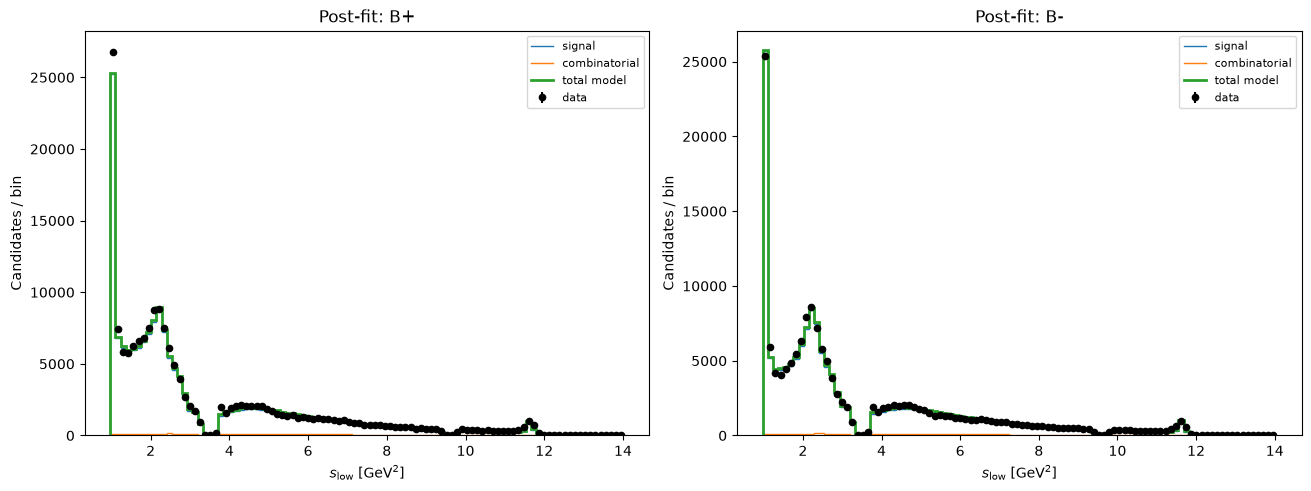

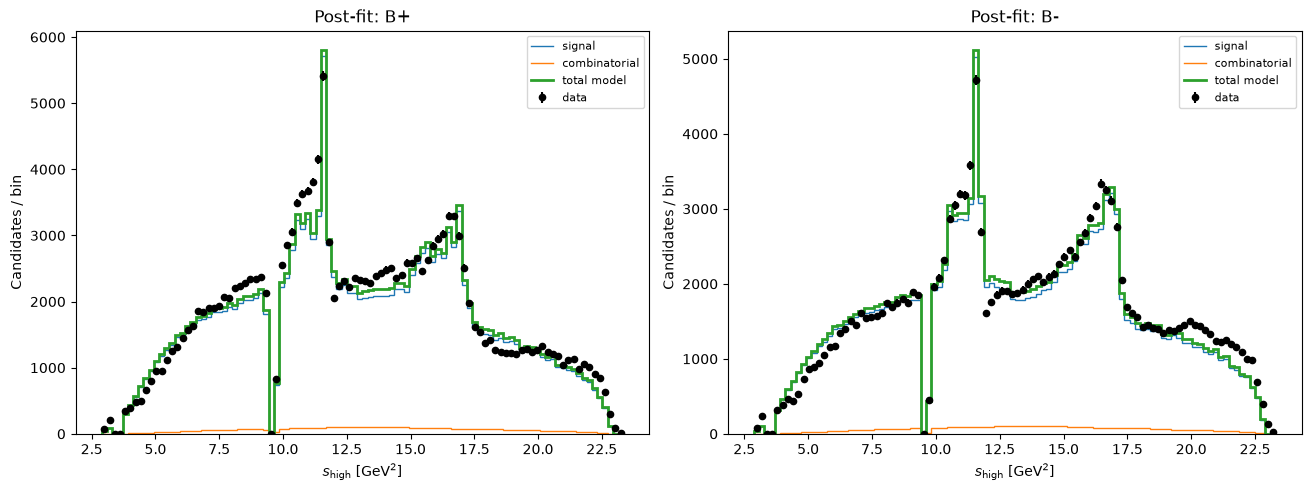

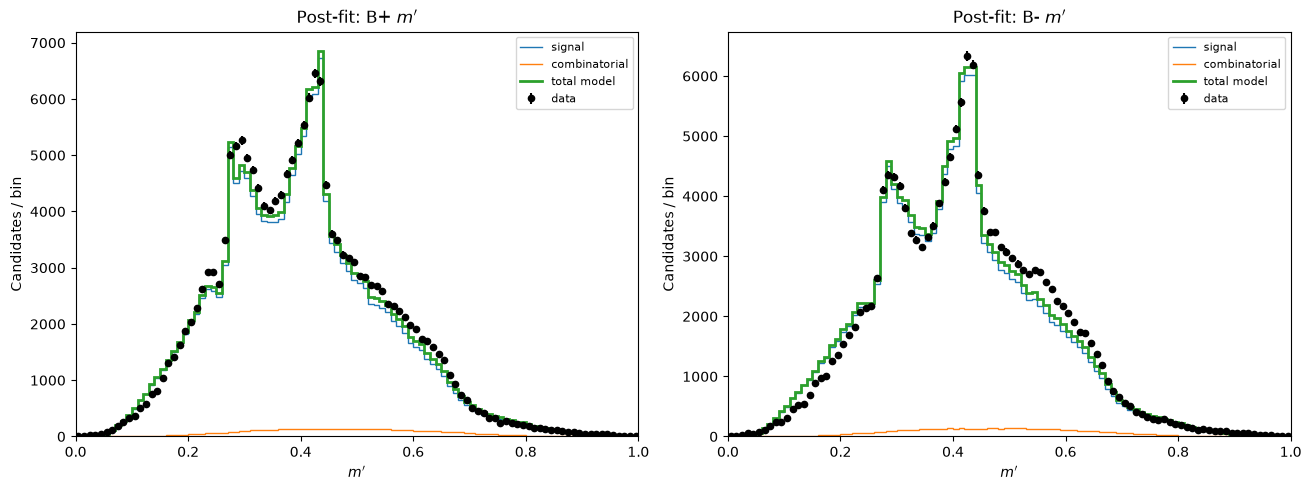

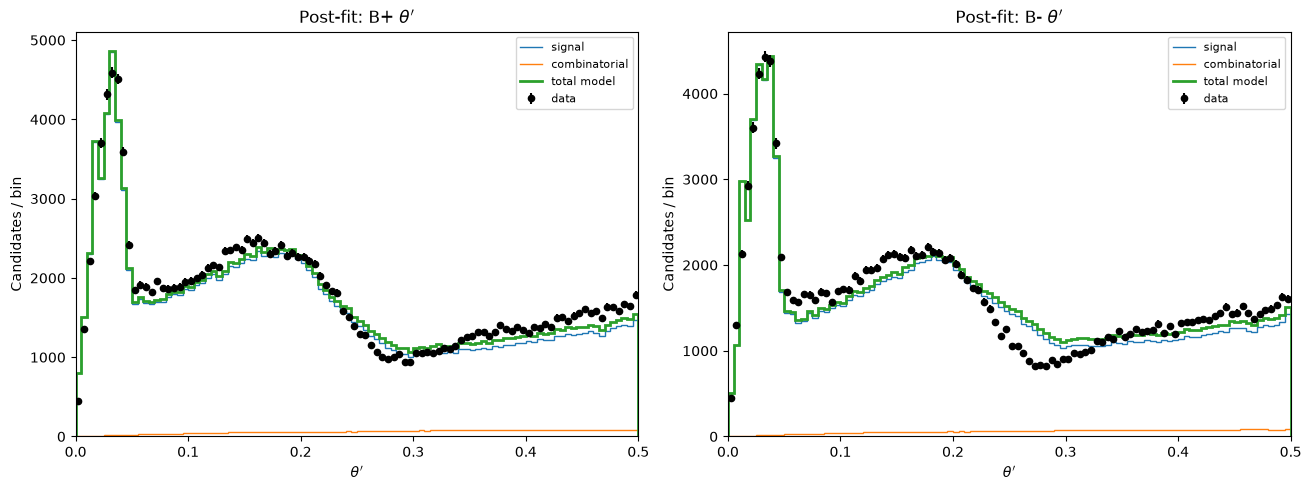

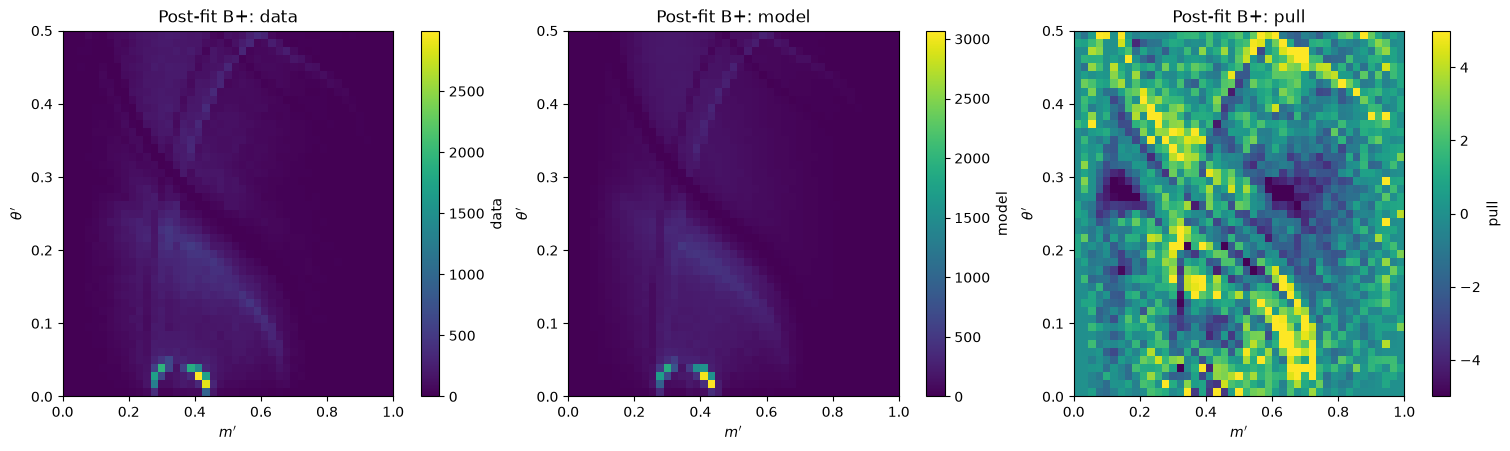

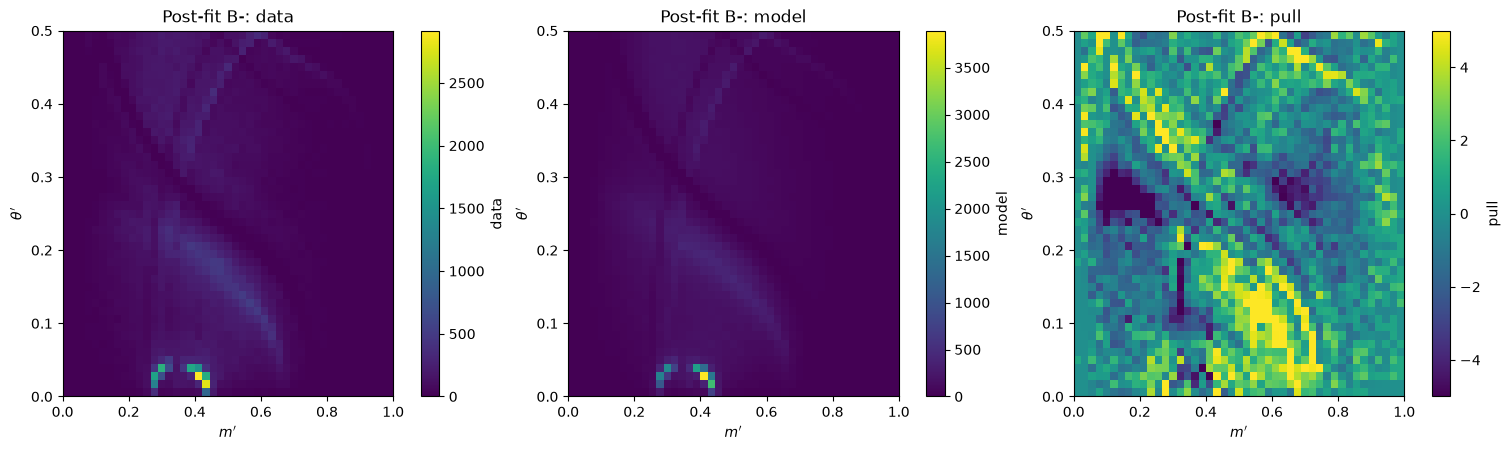

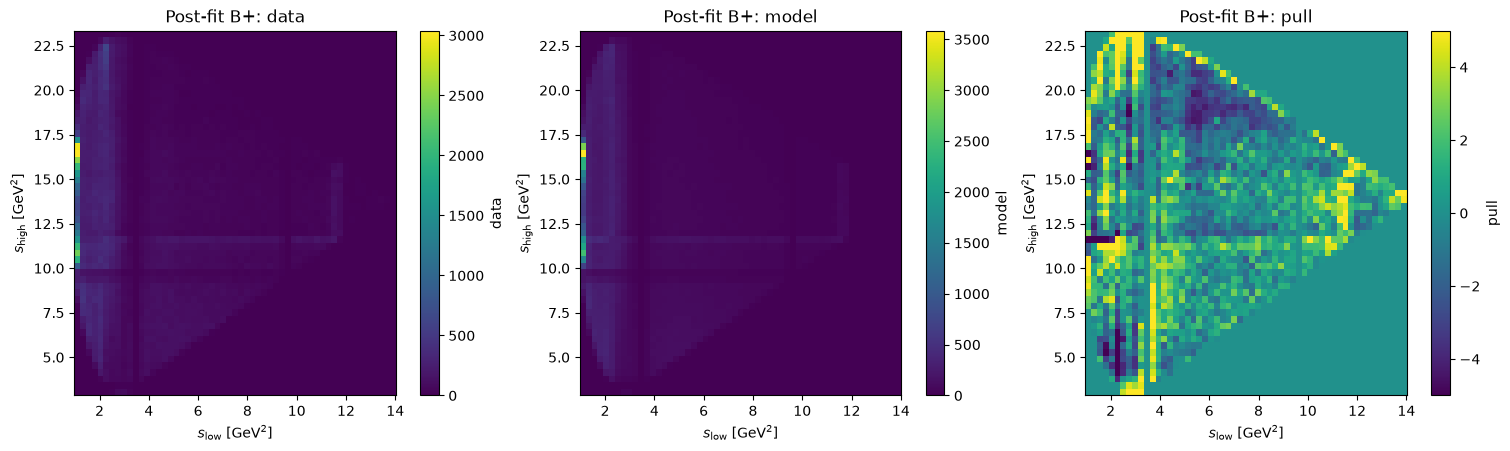

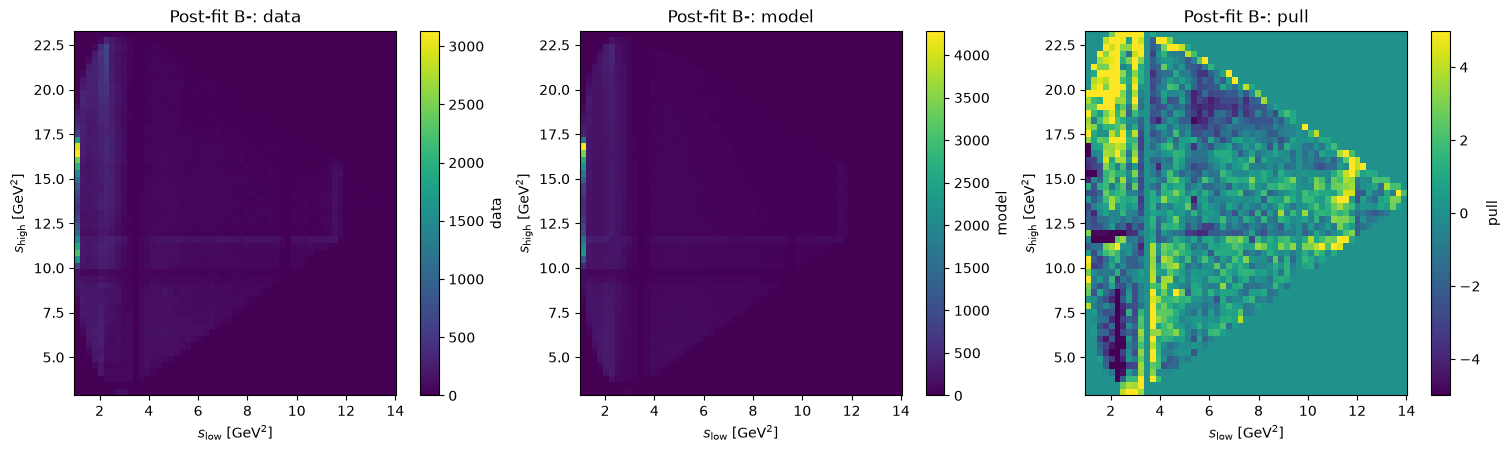

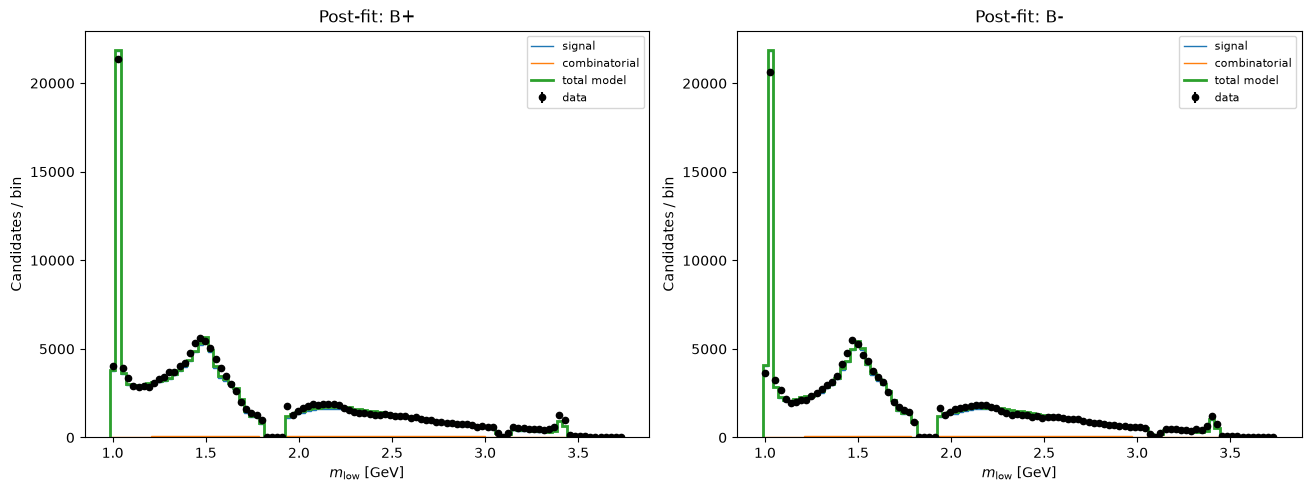

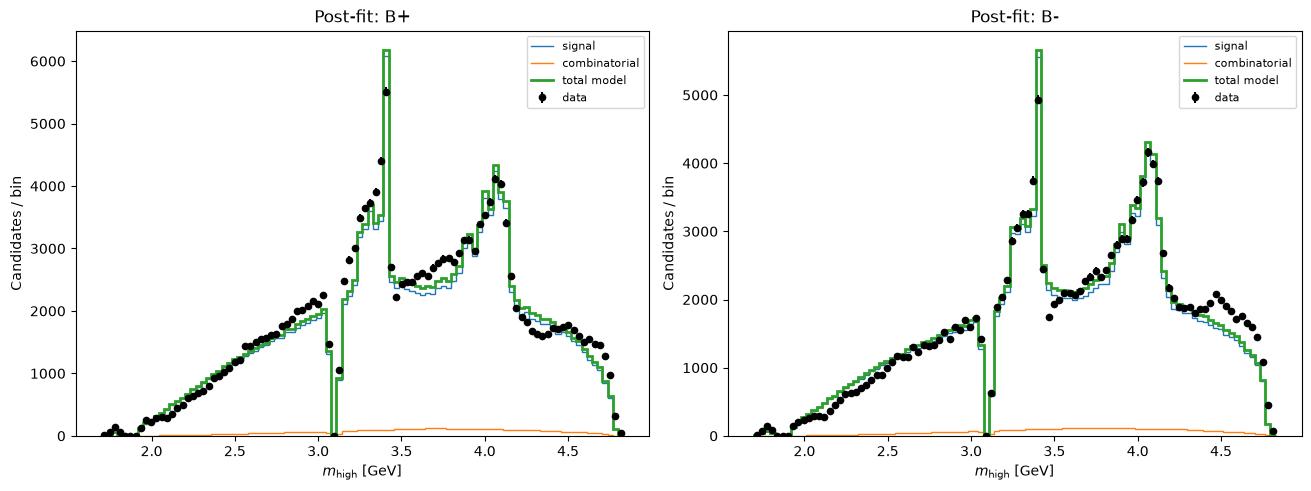

In [13]:
postfit_values = session.result_values(result)

plot_all_diagnostics(
    postfit_values,
    title_prefix='Post-fit',
    seed=FIT_SEED + 5000,
)

## Folded background and efficiency

Background and efficiency are both built directly from the ROOT files' own
`mPrime`/`thPrime` branches — no invariants-to-square-Dalitz recomputation
or manual mirroring is used to build them.

The two identical \(K^+\) are particles \((0, 1)\) in `('K+', 'K+', 'K-')`;
`SQDP_PAIR = (0, 1)` is exactly this identical pair (verified numerically:
using it to recompute \(m'\)/\(\theta'\) from `s12`/`s13`/`s23` with the
per-candidate mass reproduces the stored ROOT `mPrime`/`thPrime` branches).
`thPrime` in the ROOT files is already folded onto `[0, 0.5]`, so the
histogram is built directly on that half-domain and handed to
`SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` with
`folded=True`, `pair=SQDP_PAIR` — evaluation (on the fit's own `s12`/`s13`/
`s23`) recomputes \(m'\)/\(\theta'\) internally and folds any query point
onto the same half, so no explicit unfolding/mirroring step is required.

Postfit SqDP data panels (`plot_sqdp_projections`, `plot_sqdp_comparison`)
also plot the real `mPrime`/`thPrime` branches directly (`signal_sqdp`,
masked by the same `CHARM_VETO` as `samples`) instead of recomputing them;
only the generated toy/component samples, which carry only `(s12, s13,
s23)`, go through `square_coordinates`.

The fit itself normalizes with `toy-mc`: a single flat 1,000,000-event
`PhaseSpaceMC` sample, generated once and passed as `normalization_sample=`
to both the B+ and B- models, so no new integration points are drawn during
minimization and both charges share identical integration noise
(`docs/mc_integration.md`).